# Laboratorio 06 — MIMO: Canal, Capacidad y Precodificación

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ollerenac/wireless-communication-systems/blob/main/docs/sessions/06-mimo-systems/lab.ipynb)

**Objetivos:**
- Construir realizaciones del canal MIMO i.i.d. Rayleigh y visualizar su estructura matricial
- Descomponer H vía SVD y obtener los subcanales paralelos independientes
- Calcular la capacidad ergódica MIMO y verificar el escalado lineal con N antenas
- Simular precodificadores MRT y ZF en un sistema multiusuario y comparar su BER
- Demostrar channel hardening y favorable propagation en el régimen Massive MIMO

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import os

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.figsize': (10, 5),
})
os.makedirs('figures', exist_ok=True)

rng = np.random.default_rng(42)

def Q(x):
    return 0.5 * erfc(x / np.sqrt(2))

def iid_rayleigh(Nr, Nt, rng=rng):
    """Generate one realization of an Nr×Nt i.i.d. CN(0,1) channel."""
    return (rng.standard_normal((Nr, Nt)) + 1j * rng.standard_normal((Nr, Nt))) / np.sqrt(2)

/home/researcher/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---
## Figura 1 — Configuraciones SISO, SIMO, MISO, MIMO

Diagrama conceptual que muestra las cuatro configuraciones de antenas y sus capacidades características.

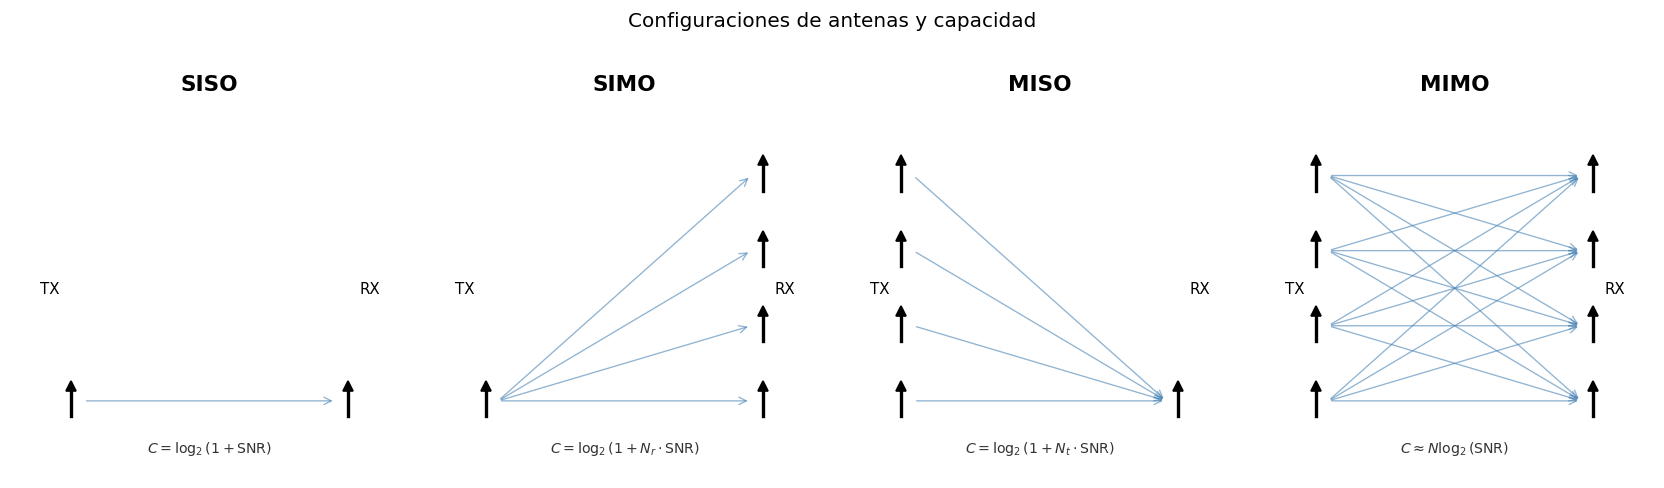

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

configs = [
    ('SISO', 1, 1, r'$C = \log_2(1+\mathrm{SNR})$'),
    ('SIMO', 1, 4, r'$C = \log_2(1+N_r\cdot\mathrm{SNR})$'),
    ('MISO', 4, 1, r'$C = \log_2(1+N_t\cdot\mathrm{SNR})$'),
    ('MIMO', 4, 4, r'$C \approx N\log_2(\mathrm{SNR})$'),
]

for ax, (name, Nt, Nr, cap) in zip(axes, configs):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(name, fontweight='bold', fontsize=13)

    tx_ys = np.linspace(0.2, 0.8, Nt)
    rx_ys = np.linspace(0.2, 0.8, Nr)

    # Draw TX antennas
    for y in tx_ys:
        ax.plot([0.15, 0.15], [y - 0.04, y + 0.04], 'k-', lw=2)
        ax.plot([0.15], [y + 0.04], 'k^', ms=6)

    # Draw RX antennas
    for y in rx_ys:
        ax.plot([0.85, 0.85], [y - 0.04, y + 0.04], 'k-', lw=2)
        ax.plot([0.85], [y + 0.04], 'k^', ms=6)

    # Draw channel links
    for yt in tx_ys:
        for yr in rx_ys:
            ax.annotate('', xy=(0.82, yr), xytext=(0.18, yt),
                        arrowprops=dict(arrowstyle='->', color='steelblue', lw=0.8, alpha=0.6))

    ax.text(0.5, 0.05, cap, ha='center', va='bottom', fontsize=8.5,
            color='#333333', style='italic')
    ax.text(0.12, 0.5, 'TX', ha='right', va='center', fontsize=9)
    ax.text(0.88, 0.5, 'RX', ha='left', va='center', fontsize=9)

plt.suptitle('Configuraciones de antenas y capacidad', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/mimo-configurations.png', bbox_inches='tight')
plt.show()

---
## Figura 2 — Estructura de la Matriz de Canal H

Visualiza la magnitud y fase de una realización $4\times4$ del canal i.i.d. Rayleigh.

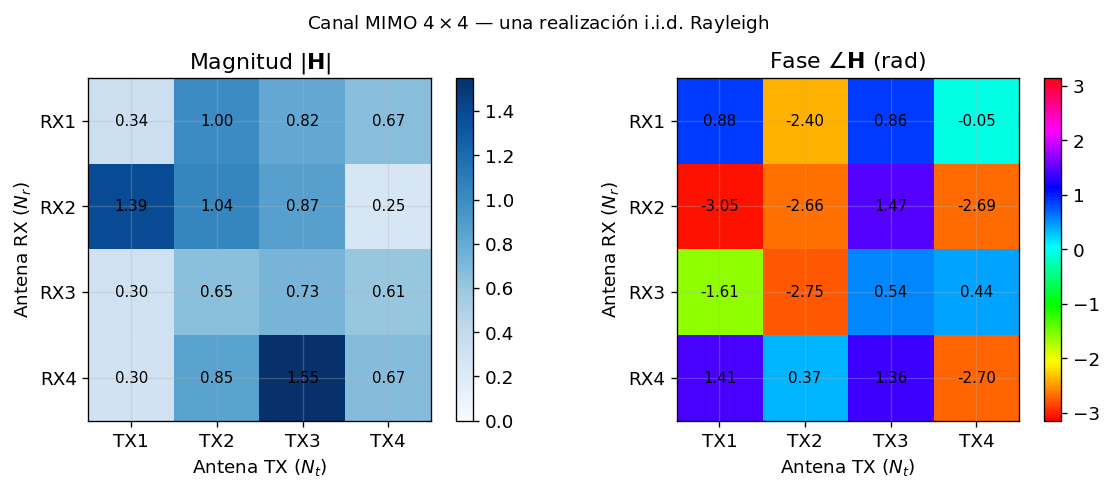

In [3]:
H = iid_rayleigh(4, 4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = ax1.imshow(np.abs(H), cmap='Blues', vmin=0, aspect='equal')
ax1.set_title(r'Magnitud $|\mathbf{H}|$')
ax1.set_xlabel('Antena TX ($N_t$)')
ax1.set_ylabel('Antena RX ($N_r$)')
ax1.set_xticks(range(4)); ax1.set_yticks(range(4))
ax1.set_xticklabels([f'TX{i+1}' for i in range(4)])
ax1.set_yticklabels([f'RX{i+1}' for i in range(4)])
for i in range(4):
    for j in range(4):
        ax1.text(j, i, f'{np.abs(H[i,j]):.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(np.angle(H), cmap='hsv', vmin=-np.pi, vmax=np.pi, aspect='equal')
ax2.set_title(r'Fase $\angle\mathbf{H}$ (rad)')
ax2.set_xlabel('Antena TX ($N_t$)')
ax2.set_ylabel('Antena RX ($N_r$)')
ax2.set_xticks(range(4)); ax2.set_yticks(range(4))
ax2.set_xticklabels([f'TX{i+1}' for i in range(4)])
ax2.set_yticklabels([f'RX{i+1}' for i in range(4)])
for i in range(4):
    for j in range(4):
        ax2.text(j, i, f'{np.angle(H[i,j]):.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im2, ax=ax2)

plt.suptitle(r'Canal MIMO $4\times4$ — una realización i.i.d. Rayleigh', fontsize=11)
plt.tight_layout()
plt.savefig('figures/mimo-channel-matrix.png', bbox_inches='tight')
plt.show()

---
## Ejercicio 1 — Descomposición SVD del Canal MIMO

La SVD $\mathbf{H} = \mathbf{U}\mathbf{\Sigma}\mathbf{V}^{\mathsf{H}}$ transforma el canal matricial en subcanales escalares independientes.

**Tareas:**
1. Genera $N_\text{mc} = 1000$ realizaciones de $\mathbf{H}_{4\times4}$ i.i.d. Rayleigh y calcula los valores singulares de cada una.
2. Grafica el histograma de los valores singulares. Compara con la distribución de Marchenko-Pastur (proporcionada).
3. Verifica que $\|\mathbf{H}\|_F^2 = \sum_k \sigma_k^2$ para varias realizaciones.
4. Genera la Figura 3: diagrama que muestra el canal MIMO (izquierda) transformado en $r$ canales paralelos (derecha).

In [4]:
# --- Marchenko-Pastur distribution (reference) ---
# For an Nr×Nt matrix with i.i.d. CN(0,1/Nr) entries, as Nr,Nt→∞ with Nt/Nr→beta,
# the empirical singular value squared distribution converges to Marchenko-Pastur.
# Here we plot empirical histograms for finite Nr=Nt=4.

Nr, Nt = 4, 4
N_mc = 2000

all_singvals = []
for _ in range(N_mc):
    H = iid_rayleigh(Nr, Nt)
    sv = np.linalg.svd(H, compute_uv=False)  # singular values, descending
    all_singvals.extend(sv.tolist())

all_singvals = np.array(all_singvals)

# --- TODO: Add your code here ---
# Plot histogram of singular values (all_singvals) using plt.hist()
# Label axes: x = 'Valor singular σ_k', y = 'Densidad'
# Also verify ||H||_F^2 == sum(σ_k^2) for one realization
# Save as 'figures/mimo-svd-channels.png'
# --- END TODO ---

# Hint for Marchenko-Pastur PDF (lambda = sigma^2, beta = Nt/Nr = 1):
# lambda_plus = (1 + sqrt(beta))^2, lambda_minus = (1 - sqrt(beta))^2
# p(lambda) = sqrt((lambda_plus - lambda)(lambda - lambda_minus)) / (2*pi*beta*lambda)
print('Mean singular value:', np.mean(all_singvals))
print('Expected (chi distribution mean for CN(0,1)):', np.sqrt(np.pi/4) * 2)

Mean singular value: 1.7086275484260063
Expected (chi distribution mean for CN(0,1)): 1.7724538509055159


---
## Figura 4 — Capacidad Ergódica MIMO vs SNR

Calcular la capacidad media (ergódica) del canal i.i.d. Rayleigh para varias configuraciones de antenas.

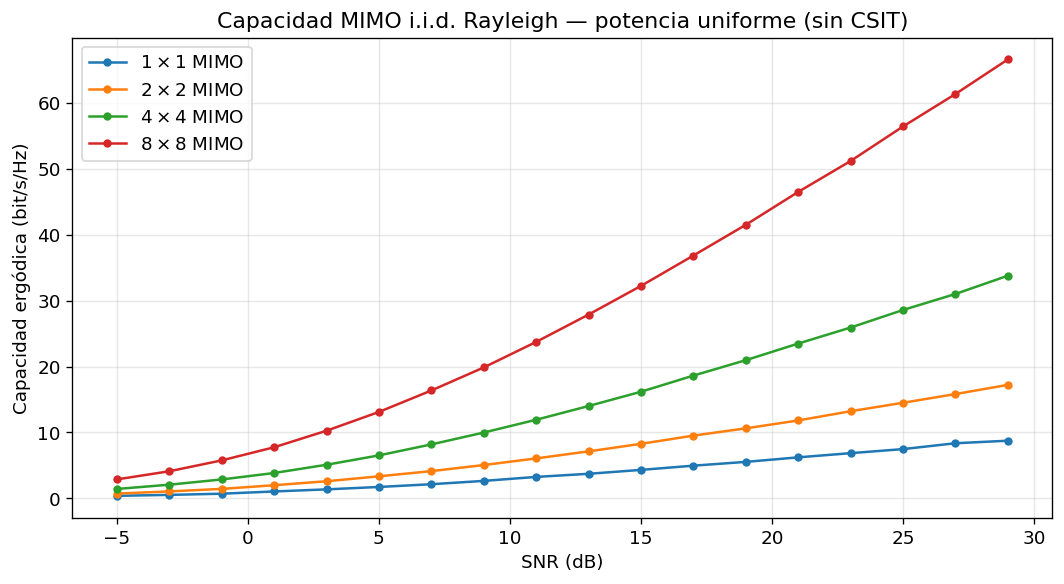

In [5]:
def mimo_capacity_ergodic(Nr, Nt, snr_db, N_mc=500, rng=rng):
    """Ergodic capacity [bit/s/Hz] with equal power allocation (no CSIT)."""
    snr = 10 ** (snr_db / 10)
    caps = []
    for _ in range(N_mc):
        H = iid_rayleigh(Nr, Nt, rng)
        # Capacity: log2 det(I + snr/Nt * H @ H.H)
        HHH = H @ H.conj().T
        eigvals = np.linalg.eigvalsh(HHH).clip(0)  # eigenvalues of H*H^H >= 0
        caps.append(np.sum(np.log2(1 + snr / Nt * eigvals)))
    return np.mean(caps)

snr_db_range = np.arange(-5, 31, 2)
configs = [(1, 1), (2, 2), (4, 4), (8, 8)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(9, 5))

for (Nr, Nt), color in zip(configs, colors):
    caps = [mimo_capacity_ergodic(Nr, Nt, snr) for snr in snr_db_range]
    ax.plot(snr_db_range, caps, '-o', ms=4, color=color,
            label=f'${Nr}\\times{Nt}$ MIMO')

ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Capacidad ergódica (bit/s/Hz)')
ax.set_title('Capacidad MIMO i.i.d. Rayleigh — potencia uniforme (sin CSIT)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/mimo-capacity.png', bbox_inches='tight')
plt.show()

---
## Figura 5 — Curva DMT

El compromiso diversidad-multiplexación $d^*(r) = (N_t - r)(N_r - r)$ determina qué ganancia se puede obtener para cada número de streams $r$.

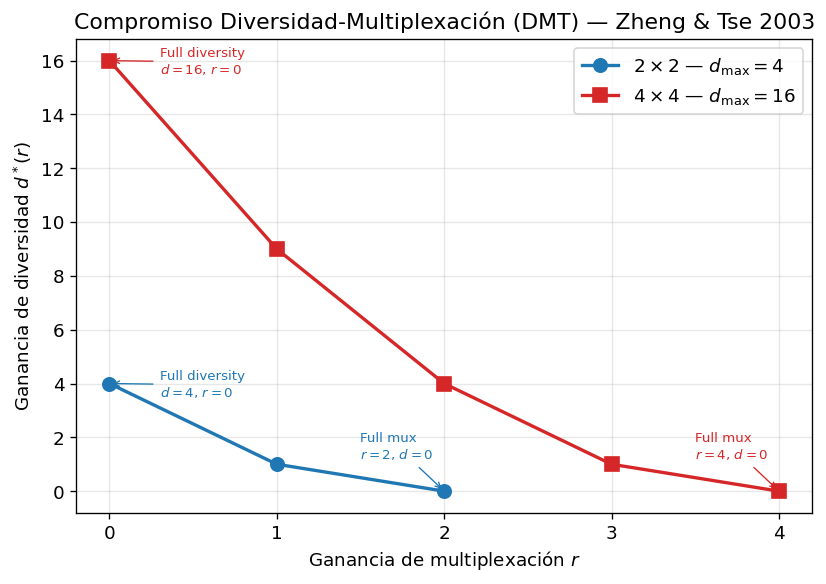

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

for (Nt, Nr), color, ls in [((2, 2), '#1f77b4', '-o'), ((4, 4), '#d62728', '-s')]:
    r_vals = np.arange(0, min(Nt, Nr) + 1)
    d_vals = (Nt - r_vals) * (Nr - r_vals)
    ax.plot(r_vals, d_vals, ls, color=color, ms=8, lw=2,
            label=f'${Nt}\\times{Nr}$ — $d_{{\\max}}={Nt*Nr}$')

    # Annotate extreme points
    ax.annotate(f'Full diversity\n$d={Nt*Nr}$, $r=0$',
                xy=(0, Nt * Nr), xytext=(0.3, Nt * Nr - 0.5),
                fontsize=8, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))
    ax.annotate(f'Full mux\n$r={min(Nt,Nr)}$, $d=0$',
                xy=(min(Nt, Nr), 0), xytext=(min(Nt, Nr) - 0.5, 1.2),
                fontsize=8, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

ax.set_xlabel('Ganancia de multiplexación $r$')
ax.set_ylabel('Ganancia de diversidad $d^*(r)$')
ax.set_title('Compromiso Diversidad-Multiplexación (DMT) — Zheng & Tse 2003')
ax.legend()
ax.set_xticks(range(5))
plt.tight_layout()
plt.savefig('figures/mimo-dmt.png', bbox_inches='tight')
plt.show()

---
## Ejercicio 2 — Precodificadores MRT y ZF

Sistema MU-MIMO con $M=8$ antenas en la BS y $K=4$ usuarios con una antena cada uno.

El canal de bajada es $\mathbf{y} = \mathbf{H}\mathbf{W}\mathbf{s} + \mathbf{n}$ con $\mathbf{H} \in \mathbb{C}^{K\times M}$.

**Tareas:**
1. Implementa `precoder_mrt(H)` que devuelva $\mathbf{W} = \mathbf{H}^{\mathsf{H}}$ normalizado por potencia.
2. Implementa `precoder_zf(H)` que devuelva $\mathbf{W} = \mathbf{H}^{\mathsf{H}}(\mathbf{H}\mathbf{H}^{\mathsf{H}})^{-1}$ normalizado.
3. Simula la BER (QPSK) de los $K$ usuarios para cada precoder vs SNR.
4. Genera la Figura 6: curvas BER MRT vs ZF, identifica el cruce.

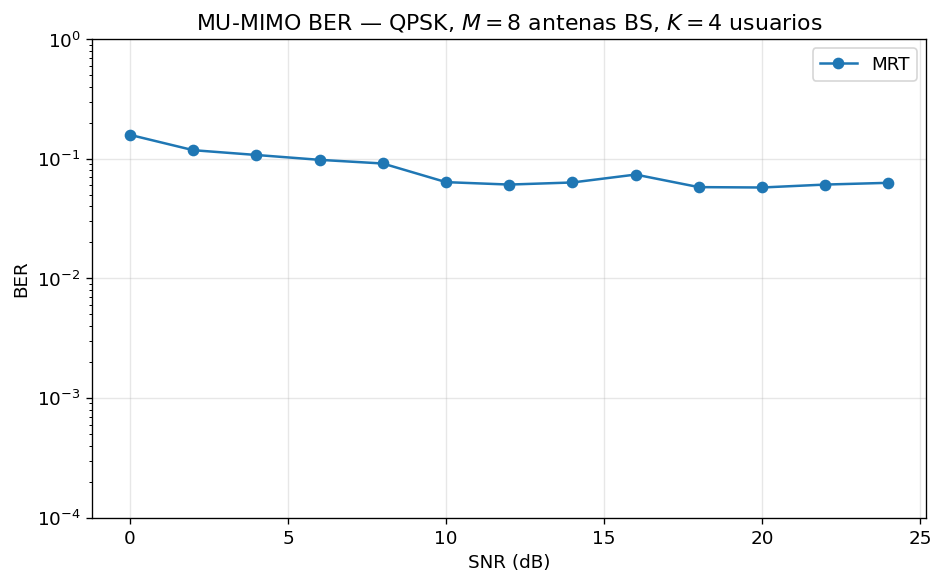

In [7]:
def normalize_precoder(W):
    """Normalize precoder so total transmitted power = 1."""
    return W / np.linalg.norm(W, 'fro')

def precoder_mrt(H):
    """Maximum Ratio Transmission precoder."""
    W = H.conj().T          # shape: (M, K)
    return normalize_precoder(W)

def precoder_zf(H):
    """Zero-Forcing precoder via pseudo-inverse."""
    # TODO: implement ZF precoder
    # W = H^H (H H^H)^{-1}, then normalize
    # Hint: np.linalg.pinv(H) computes the Moore-Penrose pseudoinverse
    pass

def simulate_ber_mu_mimo(M, K, precoder_fn, snr_db_vals, N_mc=300, modulation='QPSK'):
    """Monte Carlo BER simulation for MU-MIMO downlink."""
    bers = []
    for snr_db in snr_db_vals:
        snr = 10 ** (snr_db / 10)
        errors = 0
        total_bits = 0
        for _ in range(N_mc):
            H = iid_rayleigh(K, M)              # (K, M) downlink channel
            W = precoder_fn(H)                  # (M, K) precoder

            # QPSK symbols: ±1/√2 ± j/√2
            bits = rng.integers(0, 2, size=(K, 2))
            s = (2 * bits[:, 0] - 1 + 1j * (2 * bits[:, 1] - 1)) / np.sqrt(2)

            # Received signal
            x = W @ s                           # (M,)
            noise = (rng.standard_normal(K) + 1j * rng.standard_normal(K)) / np.sqrt(2 * snr)
            y = H @ x + noise                   # (K,)

            # Detect (nearest QPSK point, assuming perfect per-user equalization)
            bits_hat = np.stack([(y.real > 0).astype(int), (y.imag > 0).astype(int)], axis=1)
            errors += np.sum(bits_hat != bits)
            total_bits += K * 2
        bers.append(errors / total_bits)
    return np.array(bers)

M, K = 8, 4
snr_range = np.arange(0, 26, 2)

ber_mrt = simulate_ber_mu_mimo(M, K, precoder_mrt, snr_range)
# ber_zf = simulate_ber_mu_mimo(M, K, precoder_zf, snr_range)  # uncomment after implementing ZF

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(snr_range, ber_mrt, '-o', label='MRT', color='#1f77b4')
# ax.semilogy(snr_range, ber_zf, '-s', label='ZF', color='#d62728')  # uncomment after ZF
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('BER')
ax.set_title(f'MU-MIMO BER — QPSK, $M={M}$ antenas BS, $K={K}$ usuarios')
ax.set_ylim(1e-4, 1)
ax.legend()
plt.tight_layout()
plt.savefig('figures/mimo-mrt-zf.png', bbox_inches='tight')
plt.show()

---
## Ejercicio 3 — Massive MIMO: Channel Hardening y Favorable Propagation

**Tareas:**
1. Fija $K=4$ usuarios con $\beta_k = 1$ para todos. Varía $M \in \{4, 8, 16, 32, 64, 128, 256\}$.
2. Para cada $M$, genera $N_\text{mc} = 1000$ realizaciones y calcula $\|\mathbf{h}_k\|^2/M$ para el usuario $k=1$.
   - Grafica el histograma de esta cantidad para $M = \{4, 16, 64, 256\}$. ¿Qué ocurre conforme $M$ crece?
3. Para los mismos $M$, calcula el producto interno normalizado $|\mathbf{h}_1^{\mathsf{H}}\mathbf{h}_2|/M$.
   - Grafica su distribución y verifica la convergencia a 0 (favorable propagation).
4. Genera la Figura 7 (dos paneles: hardening a la izquierda, favorable propagation a la derecha).

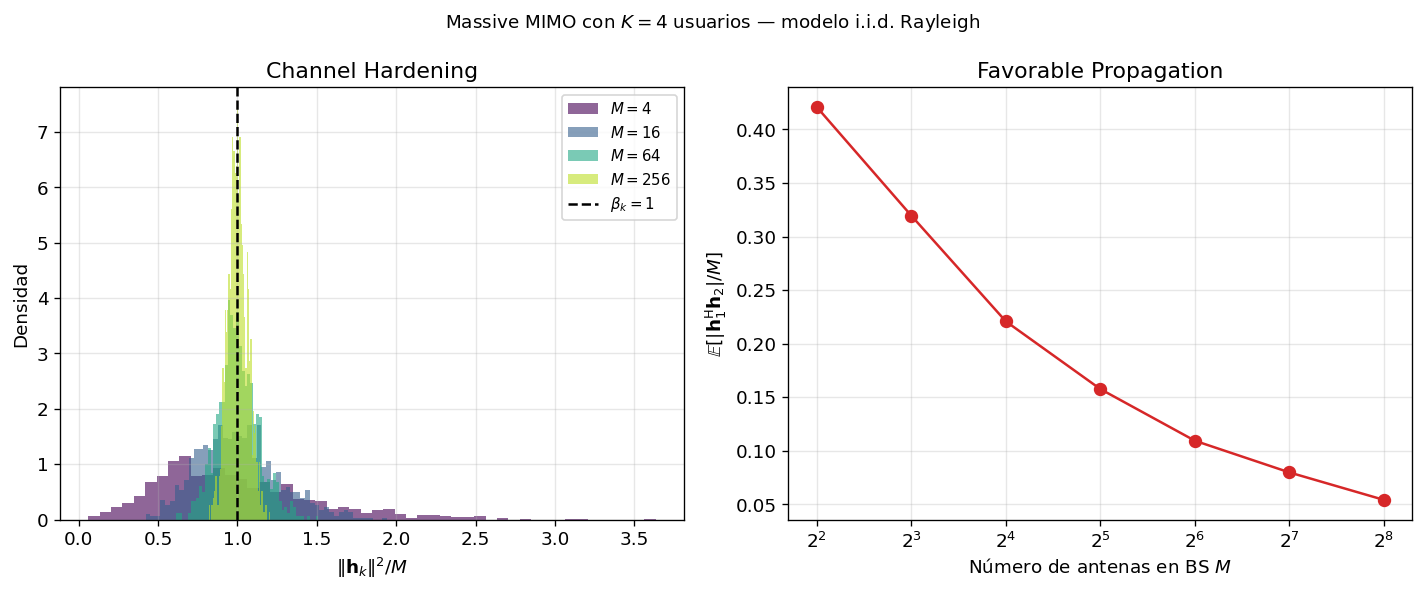

Mean ||h||^2/M for M=256: 1.0020030465884768
Std ||h||^2/M for M=256: 0.06269241055524034


In [8]:
M_vals = [4, 8, 16, 32, 64, 128, 256]
K = 4
N_mc = 1000

# Channel hardening: ||h_k||^2 / M for user k=0
hardening_data = {}   # M -> array of ||h_0||^2/M values
ortho_data = {}       # M -> array of |h_0^H h_1|/M values

for M in M_vals:
    norms = []
    cross = []
    for _ in range(N_mc):
        H = iid_rayleigh(K, M)  # (K, M), each row is one user's channel vector
        h0 = H[0]               # user 0
        h1 = H[1]               # user 1
        norms.append(np.linalg.norm(h0)**2 / M)
        cross.append(abs(h0.conj() @ h1) / M)
    hardening_data[M] = np.array(norms)
    ortho_data[M] = np.array(cross)

# --- Figura 7 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors_M = plt.cm.viridis(np.linspace(0, 0.9, 4))
for (M, color) in zip([4, 16, 64, 256], colors_M):
    ax1.hist(hardening_data[M], bins=50, density=True, alpha=0.6,
             color=color, label=f'$M={M}$')
ax1.axvline(1.0, color='k', ls='--', lw=1.5, label=r'$\beta_k = 1$')
ax1.set_xlabel(r'$\|\mathbf{h}_k\|^2 / M$')
ax1.set_ylabel('Densidad')
ax1.set_title('Channel Hardening')
ax1.legend(fontsize=9)

mean_cross = [np.mean(ortho_data[M]) for M in M_vals]
ax2.plot(M_vals, mean_cross, '-o', color='#d62728', ms=7)
ax2.set_xscale('log', base=2)
ax2.set_xlabel('Número de antenas en BS $M$')
ax2.set_ylabel(r'$\mathbb{E}[|\mathbf{h}_1^{\mathsf{H}}\mathbf{h}_2| / M]$')
ax2.set_title('Favorable Propagation')

plt.suptitle(f'Massive MIMO con $K={K}$ usuarios — modelo i.i.d. Rayleigh', fontsize=11)
plt.tight_layout()
plt.savefig('figures/mimo-massive.png', bbox_inches='tight')
plt.show()

print('Mean ||h||^2/M for M=256:', np.mean(hardening_data[256]))
print('Std ||h||^2/M for M=256:', np.std(hardening_data[256]))

---
## Figura 8 — Sum-Rate: MRT vs ZF vs Óptimo

Comparación de la suma de tasas (sum-rate) de los $K$ usuarios para MRT, ZF y el precodificador óptimo (cota superior) en función de $M$.

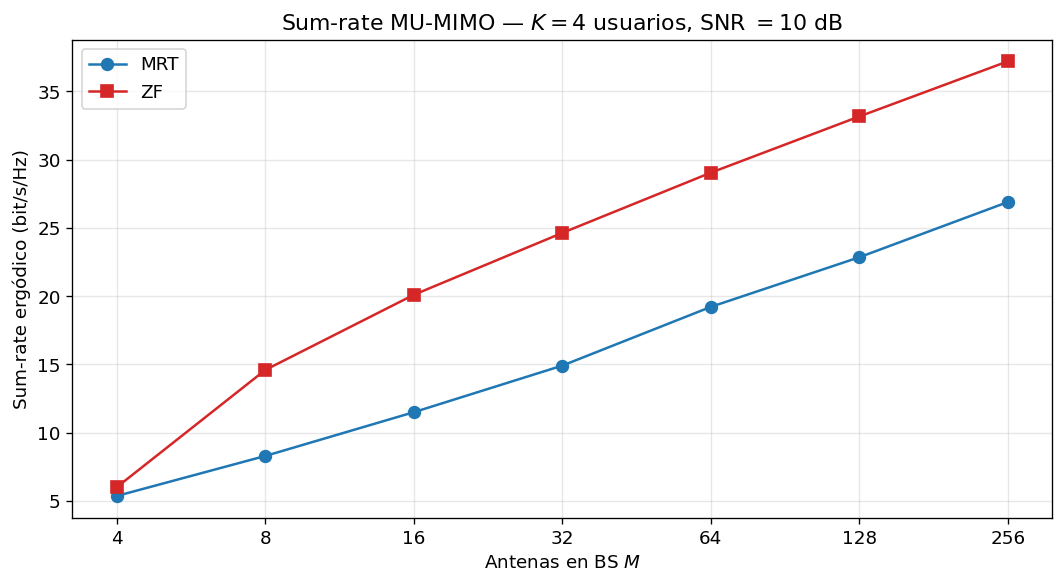

In [9]:
def sum_rate_mrt(H, snr):
    """Sum-rate for MRT precoder (lower bound via per-user SINR)."""
    K, M = H.shape
    W = H.conj().T
    HW = H @ W  # (K, K): received signal matrix
    rates = []
    for k in range(K):
        signal_power = snr * abs(HW[k, k])**2
        interference = snr * sum(abs(HW[k, j])**2 for j in range(K) if j != k)
        sinr = signal_power / (interference + K)  # noise power = K (total power constraint)
        rates.append(np.log2(1 + sinr))
    return sum(rates)

def sum_rate_zf(H, snr):
    """Sum-rate for ZF precoder (no inter-user interference)."""
    K, M = H.shape
    if M < K:
        return 0.0
    W_zf = np.linalg.pinv(H)   # (M, K) Moore-Penrose pseudoinverse
    # Normalize columns
    col_norms = np.linalg.norm(W_zf, axis=0, keepdims=True)
    W_zf_norm = W_zf / col_norms
    HW = H @ W_zf_norm  # should be diagonal
    rates = []
    for k in range(K):
        snr_k = snr * abs(HW[k, k])**2 / K
        rates.append(np.log2(1 + snr_k))
    return sum(rates)

K = 4
SNR_DB = 10
snr = 10 ** (SNR_DB / 10)
M_range = [4, 8, 16, 32, 64, 128, 256]
N_mc = 200

sr_mrt, sr_zf = [], []
for M in M_range:
    mrt_vals, zf_vals = [], []
    for _ in range(N_mc):
        H = iid_rayleigh(K, M)
        mrt_vals.append(sum_rate_mrt(H, snr))
        zf_vals.append(sum_rate_zf(H, snr))
    sr_mrt.append(np.mean(mrt_vals))
    sr_zf.append(np.mean(zf_vals))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(M_range, sr_mrt, '-o', color='#1f77b4', ms=7, label='MRT')
ax.plot(M_range, sr_zf, '-s', color='#d62728', ms=7, label='ZF')
ax.set_xscale('log', base=2)
ax.set_xlabel('Antenas en BS $M$')
ax.set_ylabel('Sum-rate ergódico (bit/s/Hz)')
ax.set_title(f'Sum-rate MU-MIMO — $K={K}$ usuarios, SNR $= {SNR_DB}$ dB')
ax.legend()
ax.set_xticks(M_range)
ax.set_xticklabels(M_range)
plt.tight_layout()
plt.savefig('figures/mimo-sumrate.png', bbox_inches='tight')
plt.show()